In [5]:
import pandas as pd
import seaborn as sns
import numpy as np
import re
import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8) #Adjust the configuration of the plots we will create

#Read in the data
df = pd.read_csv(r'movies.csv')

In [6]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [7]:
df.columns

Index(['name', 'rating', 'genre', 'year', 'released', 'score', 'votes',
       'director', 'writer', 'star', 'country', 'budget', 'gross', 'company',
       'runtime'],
      dtype='object')

In [8]:
df = df[['budget','company','country','director','genre','gross','name', 'rating',
    'released','runtime','score','star', 'votes','writer','year']]

In [9]:
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col,pct_missing))

budget - 0.2831246739697444%
company - 0.002217005738132499%
country - 0.0003912363067292645%
director - 0.0%
genre - 0.0%
gross - 0.02464788732394366%
name - 0.0%
rating - 0.010041731872717789%
released - 0.0002608242044861763%
runtime - 0.0005216484089723526%
score - 0.0003912363067292645%
star - 0.00013041210224308815%
votes - 0.0003912363067292645%
writer - 0.0003912363067292645%
year - 0.0%


In [10]:
df.dtypes

budget      float64
company      object
country      object
director     object
genre        object
gross       float64
name         object
rating       object
released     object
runtime     float64
score       float64
star         object
votes       float64
writer       object
year          int64
dtype: object

In [11]:
df['budget'] = df['budget'].fillna(df['budget'].median())

In [12]:
df['budget'] = df['budget'].astype('int64')

In [13]:
df.head()

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,votes,writer,year
0,19000000,Warner Bros.,United Kingdom,Stanley Kubrick,Drama,46998772.0,The Shining,R,"June 13, 1980 (United States)",146.0,8.4,Jack Nicholson,927000.0,Stephen King,1980
1,4500000,Columbia Pictures,United States,Randal Kleiser,Adventure,58853106.0,The Blue Lagoon,R,"July 2, 1980 (United States)",104.0,5.8,Brooke Shields,65000.0,Henry De Vere Stacpoole,1980
2,18000000,Lucasfilm,United States,Irvin Kershner,Action,538375067.0,Star Wars: Episode V - The Empire Strikes Back,PG,"June 20, 1980 (United States)",124.0,8.7,Mark Hamill,1200000.0,Leigh Brackett,1980
3,3500000,Paramount Pictures,United States,Jim Abrahams,Comedy,83453539.0,Airplane!,PG,"July 2, 1980 (United States)",88.0,7.7,Robert Hays,221000.0,Jim Abrahams,1980
4,6000000,Orion Pictures,United States,Harold Ramis,Comedy,39846344.0,Caddyshack,R,"July 25, 1980 (United States)",98.0,7.3,Chevy Chase,108000.0,Brian Doyle-Murray,1980


In [14]:
df['gross'] = df['gross'].fillna(df['gross'].median())
df['gross'] = df['gross'].astype('int64')

df['runtime'] = df['runtime'].fillna(df['runtime'].median())
df['runtime'] = df['runtime'].astype('int64')

df.head()

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,votes,writer,year
0,19000000,Warner Bros.,United Kingdom,Stanley Kubrick,Drama,46998772,The Shining,R,"June 13, 1980 (United States)",146,8.4,Jack Nicholson,927000.0,Stephen King,1980
1,4500000,Columbia Pictures,United States,Randal Kleiser,Adventure,58853106,The Blue Lagoon,R,"July 2, 1980 (United States)",104,5.8,Brooke Shields,65000.0,Henry De Vere Stacpoole,1980
2,18000000,Lucasfilm,United States,Irvin Kershner,Action,538375067,Star Wars: Episode V - The Empire Strikes Back,PG,"June 20, 1980 (United States)",124,8.7,Mark Hamill,1200000.0,Leigh Brackett,1980
3,3500000,Paramount Pictures,United States,Jim Abrahams,Comedy,83453539,Airplane!,PG,"July 2, 1980 (United States)",88,7.7,Robert Hays,221000.0,Jim Abrahams,1980
4,6000000,Orion Pictures,United States,Harold Ramis,Comedy,39846344,Caddyshack,R,"July 25, 1980 (United States)",98,7.3,Chevy Chase,108000.0,Brian Doyle-Murray,1980


In [15]:
df['votes'] = df['votes'].fillna(0)
df['votes'] = df['votes'].astype('int64')

In [16]:
df['released'] = df['released'].astype('str')


In [17]:
# df.loc[df['released'] == 'nan','released'] = df['year']

In [18]:
df['year_correct'] = df['released']

In [19]:
# df.loc[1,'year_correct']

In [20]:
for index in df.index:
    if df.loc[index,'year_correct'] == 'nan':
        df.loc[index,'year_correct'] = df.loc[index,'year']
    else:
        span = re.search(r'(\d{4})', df.loc[index,'year_correct']).span()
        df.loc[index,'year_correct'] = df.loc[index,'year_correct'][int(span[0]):int(span[1])]
        
df.head()

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,votes,writer,year,year_correct
0,19000000,Warner Bros.,United Kingdom,Stanley Kubrick,Drama,46998772,The Shining,R,"June 13, 1980 (United States)",146,8.4,Jack Nicholson,927000,Stephen King,1980,1980
1,4500000,Columbia Pictures,United States,Randal Kleiser,Adventure,58853106,The Blue Lagoon,R,"July 2, 1980 (United States)",104,5.8,Brooke Shields,65000,Henry De Vere Stacpoole,1980,1980
2,18000000,Lucasfilm,United States,Irvin Kershner,Action,538375067,Star Wars: Episode V - The Empire Strikes Back,PG,"June 20, 1980 (United States)",124,8.7,Mark Hamill,1200000,Leigh Brackett,1980,1980
3,3500000,Paramount Pictures,United States,Jim Abrahams,Comedy,83453539,Airplane!,PG,"July 2, 1980 (United States)",88,7.7,Robert Hays,221000,Jim Abrahams,1980,1980
4,6000000,Orion Pictures,United States,Harold Ramis,Comedy,39846344,Caddyshack,R,"July 25, 1980 (United States)",98,7.3,Chevy Chase,108000,Brian Doyle-Murray,1980,1980


In [21]:
df['year_correct'].isnull().sum()

np.int64(0)

In [22]:
# test = df[df['year_correct'].isnull()]

# for index in df.loc[df['year_correct'].isnull(),'year_correct'].index:
#     if df.loc[index,'released'] == 'nan':
#         df.loc[index,'year_correct'] = df.loc[index,'year']
#     else: 
#         df.loc[index,'year_correct'] = df.loc[index,'released'].split()[0]

# df

In [23]:
df.sort_values(by = ['gross'], inplace = True, ascending = False)

In [24]:
# pd.set_option('display.max_rows', None)

In [25]:
# df['company'].drop_duplicates().sort_values(ascending = False)

In [26]:
df = df.drop_duplicates()

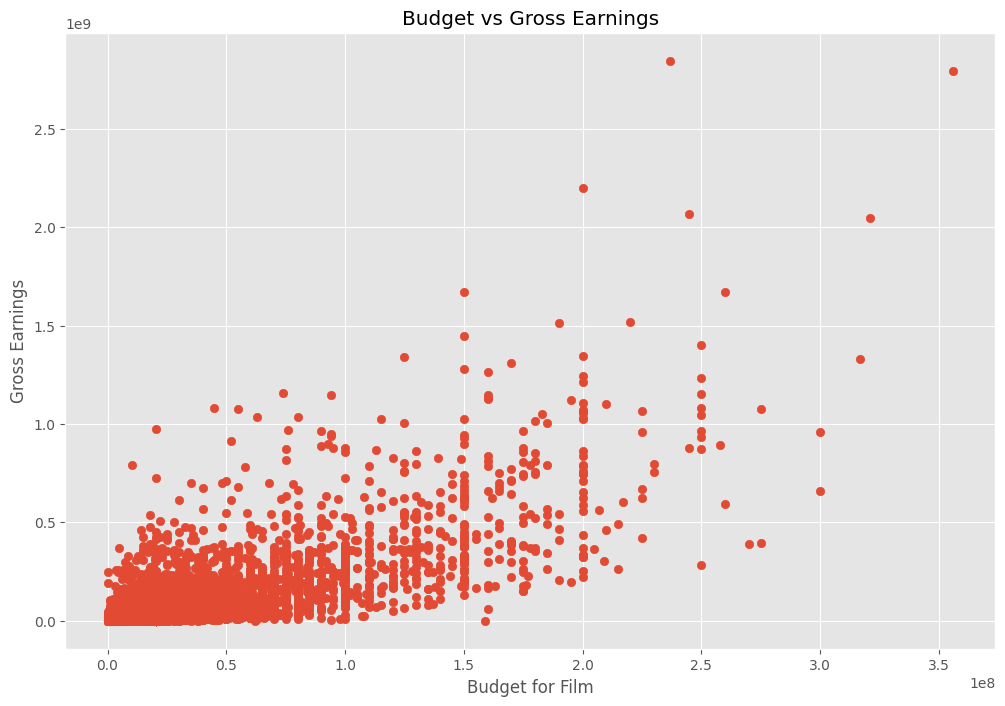

In [27]:
plt.scatter(x=df['budget'], y=df['gross'])
plt.title('Budget vs Gross Earnings')
plt.ylabel('Gross Earnings')
plt.xlabel('Budget for Film')
plt.show()

In [28]:
df.head()

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,votes,writer,year,year_correct
5445,237000000,Twentieth Century Fox,United States,James Cameron,Action,2847246203,Avatar,PG-13,"December 18, 2009 (United States)",162,7.8,Sam Worthington,1100000,James Cameron,2009,2009
7445,356000000,Marvel Studios,United States,Anthony Russo,Action,2797501328,Avengers: Endgame,PG-13,"April 26, 2019 (United States)",181,8.4,Robert Downey Jr.,903000,Christopher Markus,2019,2019
3045,200000000,Twentieth Century Fox,United States,James Cameron,Drama,2201647264,Titanic,PG-13,"December 19, 1997 (United States)",194,7.8,Leonardo DiCaprio,1100000,James Cameron,1997,1997
6663,245000000,Lucasfilm,United States,J.J. Abrams,Action,2069521700,Star Wars: Episode VII - The Force Awakens,PG-13,"December 18, 2015 (United States)",138,7.8,Daisy Ridley,876000,Lawrence Kasdan,2015,2015
7244,321000000,Marvel Studios,United States,Anthony Russo,Action,2048359754,Avengers: Infinity War,PG-13,"April 27, 2018 (United States)",149,8.4,Robert Downey Jr.,897000,Christopher Markus,2018,2018


<Axes: xlabel='budget', ylabel='gross'>

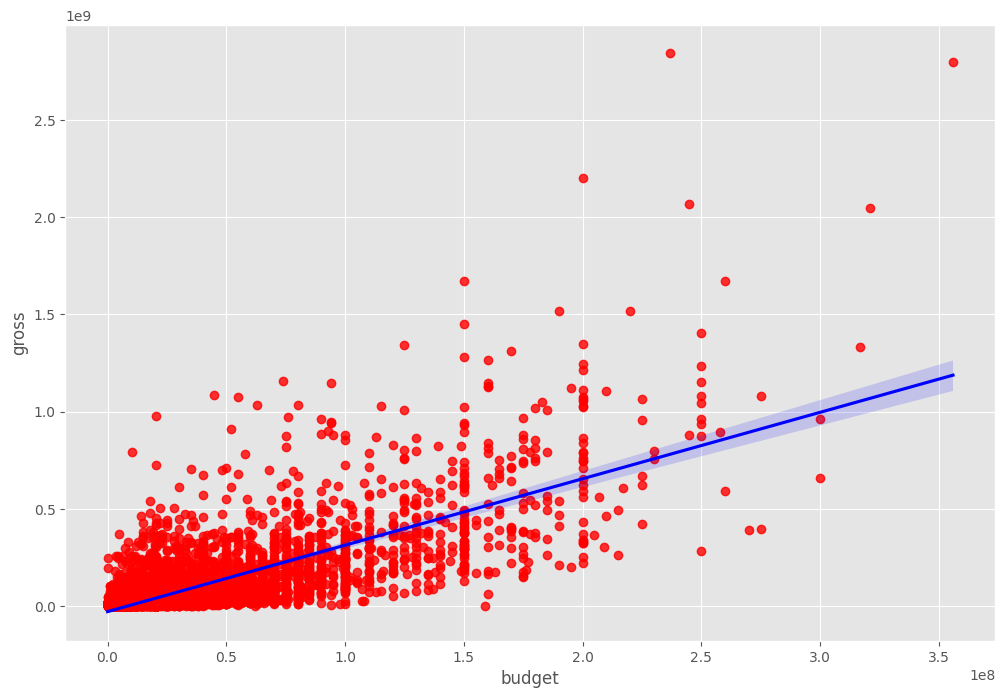

In [29]:
sns.regplot(x = 'budget', y = 'gross', data = df, scatter_kws = {"color": "red"} , line_kws={"color":"blue"})

In [30]:
df.select_dtypes(include=['int64', 'float64']).corr(method = 'pearson') #pearson (default), kendall, spearman

,budget,gross,runtime,score,votes,year
budget,1.000000,0.745881,0.273371,0.061979,0.461021,0.291690
gross,0.745881,1.000000,0.244380,0.185583,0.632125,0.259504
runtime,0.273371,0.244380,1.000000,0.399449,0.309127,0.120662
score,0.061979,0.185583,0.399449,1.000000,0.409182,0.097995
votes,0.461021,0.632125,0.309127,0.409182,1.000000,0.222427
year,0.291690,0.259504,0.120662,0.097995,0.222427,1.000000


In [31]:
#High correlation between budget and gross

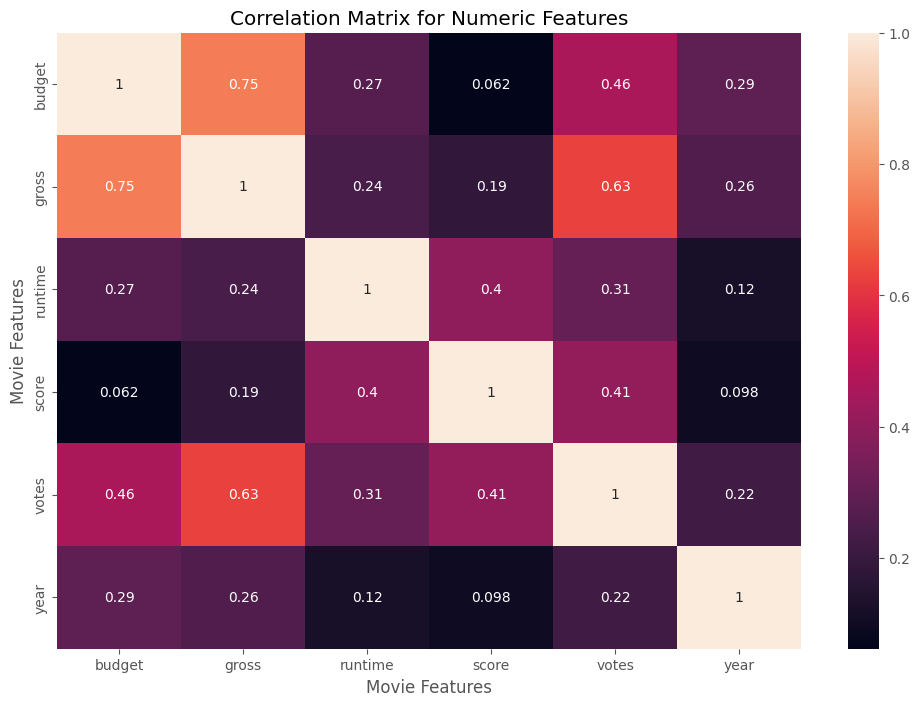

In [32]:
correlation_matrix = df.select_dtypes(include=['int64', 'float64']).corr(method = 'pearson') 
sns.heatmap(correlation_matrix, annot = True)
plt.title('Correlation Matrix for Numeric Features')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show()

In [33]:
#Look at company
df.head()

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,votes,writer,year,year_correct
5445,237000000,Twentieth Century Fox,United States,James Cameron,Action,2847246203,Avatar,PG-13,"December 18, 2009 (United States)",162,7.8,Sam Worthington,1100000,James Cameron,2009,2009
7445,356000000,Marvel Studios,United States,Anthony Russo,Action,2797501328,Avengers: Endgame,PG-13,"April 26, 2019 (United States)",181,8.4,Robert Downey Jr.,903000,Christopher Markus,2019,2019
3045,200000000,Twentieth Century Fox,United States,James Cameron,Drama,2201647264,Titanic,PG-13,"December 19, 1997 (United States)",194,7.8,Leonardo DiCaprio,1100000,James Cameron,1997,1997
6663,245000000,Lucasfilm,United States,J.J. Abrams,Action,2069521700,Star Wars: Episode VII - The Force Awakens,PG-13,"December 18, 2015 (United States)",138,7.8,Daisy Ridley,876000,Lawrence Kasdan,2015,2015
7244,321000000,Marvel Studios,United States,Anthony Russo,Action,2048359754,Avengers: Infinity War,PG-13,"April 27, 2018 (United States)",149,8.4,Robert Downey Jr.,897000,Christopher Markus,2018,2018


In [34]:
df.dtypes

budget            int64
company          object
country          object
director         object
genre            object
gross             int64
name             object
rating           object
released         object
runtime           int64
score           float64
star             object
votes             int64
writer           object
year              int64
year_correct     object
dtype: object

In [35]:
df['year_correct'] = df['year_correct'].astype('int64')

In [36]:
df_numerized = df.copy()

for col_name in df_numerized.columns:
    if (df_numerized[col_name].dtype == 'object'):
        df_numerized[col_name] = df_numerized[col_name].astype('category')
        df_numerized[col_name] = df_numerized[col_name].cat.codes
        
df_numerized.head()

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,votes,writer,year,year_correct
5445,237000000,2253,55,1155,0,2847246203,533,5,696,162,7.8,2334,1100000,1778,2009,2009
7445,356000000,1606,55,162,0,2797501328,535,5,183,181,8.4,2241,903000,743,2019,2019
3045,200000000,2253,55,1155,6,2201647264,6896,5,704,194,7.8,1595,1100000,1778,1997,1997
6663,245000000,1540,55,1125,0,2069521700,5144,5,698,138,7.8,524,876000,2550,2015,2015
7244,321000000,1606,55,162,0,2048359754,536,5,192,149,8.4,2241,897000,743,2018,2018


In [37]:
df.head()

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,votes,writer,year,year_correct
5445,237000000,Twentieth Century Fox,United States,James Cameron,Action,2847246203,Avatar,PG-13,"December 18, 2009 (United States)",162,7.8,Sam Worthington,1100000,James Cameron,2009,2009
7445,356000000,Marvel Studios,United States,Anthony Russo,Action,2797501328,Avengers: Endgame,PG-13,"April 26, 2019 (United States)",181,8.4,Robert Downey Jr.,903000,Christopher Markus,2019,2019
3045,200000000,Twentieth Century Fox,United States,James Cameron,Drama,2201647264,Titanic,PG-13,"December 19, 1997 (United States)",194,7.8,Leonardo DiCaprio,1100000,James Cameron,1997,1997
6663,245000000,Lucasfilm,United States,J.J. Abrams,Action,2069521700,Star Wars: Episode VII - The Force Awakens,PG-13,"December 18, 2015 (United States)",138,7.8,Daisy Ridley,876000,Lawrence Kasdan,2015,2015
7244,321000000,Marvel Studios,United States,Anthony Russo,Action,2048359754,Avengers: Infinity War,PG-13,"April 27, 2018 (United States)",149,8.4,Robert Downey Jr.,897000,Christopher Markus,2018,2018


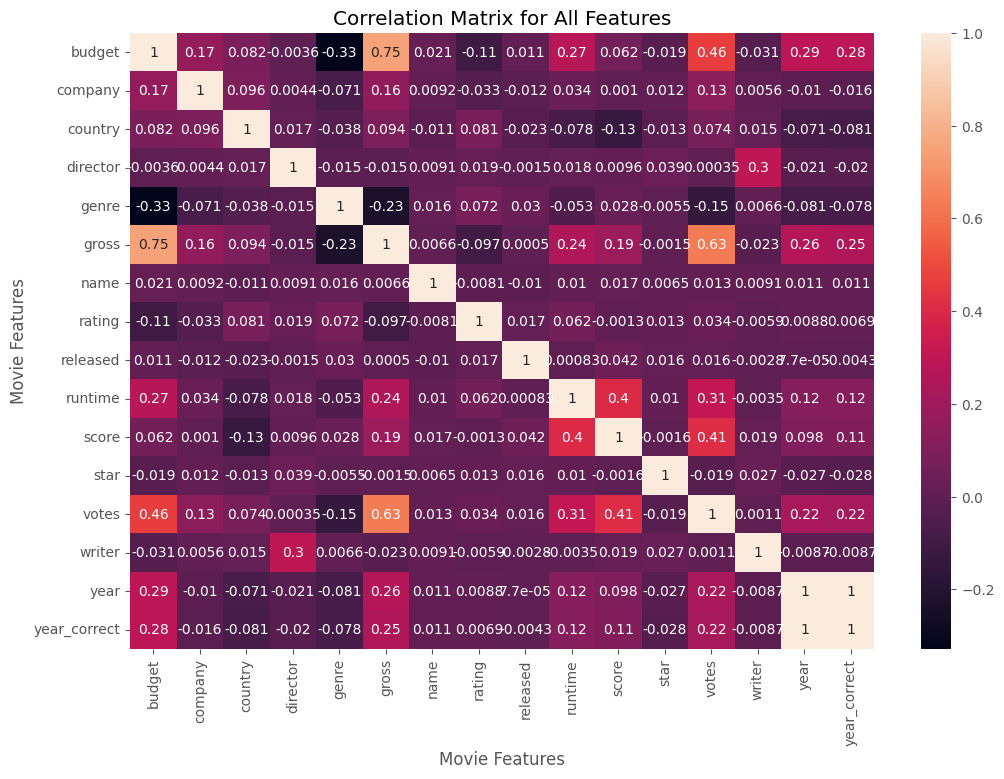

In [38]:
correlation_matrix = df_numerized.corr(method = 'pearson') 
sns.heatmap(correlation_matrix, annot = True)
plt.title('Correlation Matrix for All Features')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show()

In [39]:
correlation_mat = df_numerized.corr()
corr_pairs = correlation_mat.unstack()
corr_pairs.head()

budget  budget      1.000000
        company     0.167250
        country     0.082334
        director   -0.003584
        genre      -0.328484
dtype: float64

In [40]:
# pd.set_option('display.max_rows', None)

In [41]:
sorted_pairs = corr_pairs.sort_values()
high_corr = sorted_pairs[sorted_pairs > 0.5]
high_corr

gross         votes           0.632125
votes         gross           0.632125
gross         budget          0.745881
budget        gross           0.745881
year_correct  year            0.997416
year          year_correct    0.997416
rating        rating          1.000000
name          name            1.000000
genre         genre           1.000000
gross         gross           1.000000
company       company         1.000000
budget        budget          1.000000
country       country         1.000000
director      director        1.000000
star          star            1.000000
score         score           1.000000
released      released        1.000000
runtime       runtime         1.000000
writer        writer          1.000000
votes         votes           1.000000
year          year            1.000000
year_correct  year_correct    1.000000
dtype: float64

In [42]:
#Votes and budget have the highest correlation to gross earnings.